<a href="https://colab.research.google.com/github/Mayra-25/Alura-Store/blob/main/Alura_Store___proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Proyecto Alura store**


#**Importación de datos**

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#Consolidación y limpieza de datos


In [4]:
# Añadimos una columna para identificar de qué tienda proviene cada dato
tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

# Concatenamos todas en un solo dataframe
df_ventas = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# Revisamos la estructura general
print(df_ventas.info())
df_ventas.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9435 entries, 0 to 9434
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                9435 non-null   object 
 1   Categoría del Producto  9435 non-null   object 
 2   Precio                  9435 non-null   float64
 3   Costo de envío          9435 non-null   float64
 4   Fecha de Compra         9435 non-null   object 
 5   Vendedor                9435 non-null   object 
 6   Lugar de Compra         9435 non-null   object 
 7   Calificación            9435 non-null   int64  
 8   Método de pago          9435 non-null   object 
 9   Cantidad de cuotas      9435 non-null   int64  
 10  lat                     9435 non-null   float64
 11  lon                     9435 non-null   float64
 12  Tienda                  9435 non-null   object 
dtypes: float64(4), int64(2), object(7)
memory usage: 958.4+ KB
None


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda
199,Ajedrez de madera,Juguetes,37500.0,4400.0,20/03/2023,Izabela de León,Bucaramanga,5,Tarjeta de crédito,6,7.12539,-73.11980,Tienda 1
6578,Guitarra acústica,Instrumentos musicales,409500.0,22000.0,18/01/2023,Ángel Rodriguez,Pereira,5,Tarjeta de crédito,10,4.81333,-75.69611,Tienda 3
560,Secadora de ropa,Electrodomésticos,831500.0,42500.0,22/02/2020,Rafael Acosta,Bucaramanga,5,Tarjeta de crédito,1,7.12539,-73.11980,Tienda 1
5780,Guitarra acústica,Instrumentos musicales,435500.0,21400.0,27/03/2022,Juliana Costa,Bogotá,5,Tarjeta de crédito,4,4.60971,-74.08175,Tienda 3
2325,Mesa de noche,Muebles,327800.0,15600.0,22/07/2021,Ángel Rodriguez,Medellín,5,Cupón,1,6.25184,-75.56359,Tienda 1


In [5]:
##Verificamos si existen valores nulos
df_ventas.isnull().sum()

,0
Producto,0
Categoría del Producto,0
Precio,0
Costo de envío,0
Fecha de Compra,0
Vendedor,0
Lugar de Compra,0
Calificación,0
Método de pago,0
Cantidad de cuotas,0


In [6]:
## Verificamos si exiten valores duplicados
df_ventas.duplicated().sum()

np.int64(0)

#**Análisis de datos**

##Ingreso total por cada tienda

In [10]:
listado_tiendas = [tienda, tienda2, tienda3, tienda4]

for i, df in enumerate(listado_tiendas, 1):
    ingreso = df['Precio'].sum()
    print(f"El ingreso total de la Tienda {i} es: ${ingreso:,.2f}")

El ingreso total de la Tienda 1 es: $1,150,880,400.00
El ingreso total de la Tienda 2 es: $1,116,343,500.00
El ingreso total de la Tienda 3 es: $1,098,019,600.00
El ingreso total de la Tienda 4 es: $1,038,375,700.00


##Ventas por categoría

In [19]:
# 1. Metemos los dataframes en una lista
mis_tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

for i, df in enumerate(mis_tiendas):
    # Quitamos espacios en blanco de los nombres de las columnas
    df.columns = df.columns.str.strip()

    # BUSCADOR DINÁMICO:
    # Buscamos la columna que contenga la palabra "Categor" (así no importa si tiene tilde o no)
    try:
        col_encontrada = [c for c in df.columns if 'Categor' in c][0]

        print(f"--- Categorías más vendidas en {nombres[i]} ---")
        # Usamos el nombre de la columna que encontramos dinámicamente
        print(df[col_encontrada].value_counts())
        print("\n")

    except IndexError:
        # Si por alguna razón no encuentra nada que se parezca a "Categor"
        print(f"Error: No se encontró la columna de categoría en {nombres[i]}")
        print(f"Columnas disponibles: {df.columns.tolist()}\n")

--- Categorías más vendidas en Tienda 1 ---
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64


--- Categorías más vendidas en Tienda 2 ---
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64


--- Categorías más vendidas en Tienda 3 ---
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177

##Valoración media por tienda

In [20]:
import pandas as pd

# 1. Aseguramos que tenemos la lista de dataframes y nombres
mis_tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

print("ANÁLISIS DE SATISFACCIÓN DEL CLIENTE\n")

for i, df in enumerate(mis_tiendas):
    # LIMPIEZA: Quitamos espacios en los nombres de columnas
    df.columns = df.columns.str.strip()

    try:
        # Buscamos 'alificaci' para que coincida con Calificación o Calificacion
        col_calificacion = [c for c in df.columns if 'alificaci' in c or 'Rating' in c][0]

        # Convertimos a número por si acaso hay algún dato mal formateado
        # errors='coerce' convertirá lo que no sea número en NaN para no romper el cálculo
        calificaciones_numericas = pd.to_numeric(df[col_calificacion], errors='coerce')

        # Calculamos el promedio
        promedio = calificaciones_numericas.mean()

        print(f"--- {nombres[i]} ---")
        print(f"Calificación Promedio: {promedio:.2f} ⭐")

        # Un pequeño análisis extra: ¿Es buena o mala?
        if promedio >= 4:
            print("Estado: Excelente satisfacción.")
        elif promedio >= 3:
            print("Estado: Satisfacción regular.")
        else:
            print("Estado: Atención requerida (Satisfacción baja).")
        print("-" * 35)

    except IndexError:
        print(f"Error: No se encontró la columna de calificación en {nombres[i]}")
        print(f"Columnas detectadas: {df.columns.tolist()}\n")

ANÁLISIS DE SATISFACCIÓN DEL CLIENTE

--- Tienda 1 ---
Calificación Promedio: 3.98 ⭐
Estado: Satisfacción regular.
-----------------------------------
--- Tienda 2 ---
Calificación Promedio: 4.04 ⭐
Estado: Excelente satisfacción.
-----------------------------------
--- Tienda 3 ---
Calificación Promedio: 4.05 ⭐
Estado: Excelente satisfacción.
-----------------------------------
--- Tienda 4 ---
Calificación Promedio: 4.00 ⭐
Estado: Satisfacción regular.
-----------------------------------


##Productos más vendidos y menos vendidos

IDENTIFICANDO PRODUCTOS ESTRELLA Y MENOS VENDIDOS...

--- Tienda 1 ---
TOP Ventas: Microondas (60 unidades)
MENOS Ventas: Celular ABXY (33 unidades)
------------------------------
--- Tienda 2 ---
TOP Ventas: Iniciando en programación (65 unidades)
MENOS Ventas: Juego de mesa (32 unidades)
------------------------------
--- Tienda 3 ---
TOP Ventas: Kit de bancas (57 unidades)
MENOS Ventas: Bloques de construcción (35 unidades)
------------------------------
--- Tienda 4 ---
TOP Ventas: Cama box (62 unidades)
MENOS Ventas: Guitarra eléctrica (33 unidades)
------------------------------


/tmp/ipykernel_517/3095211221.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5.values, y=top_5.index, ax=axes[i], palette="viridis")
/tmp/ipykernel_517/3095211221.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5.values, y=top_5.index, ax=axes[i], palette="viridis")
/tmp/ipykernel_517/3095211221.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5.values, y=top_5.index, ax=axes[i], palette="viridis")
/tmp/ipykernel_517/3095211221.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

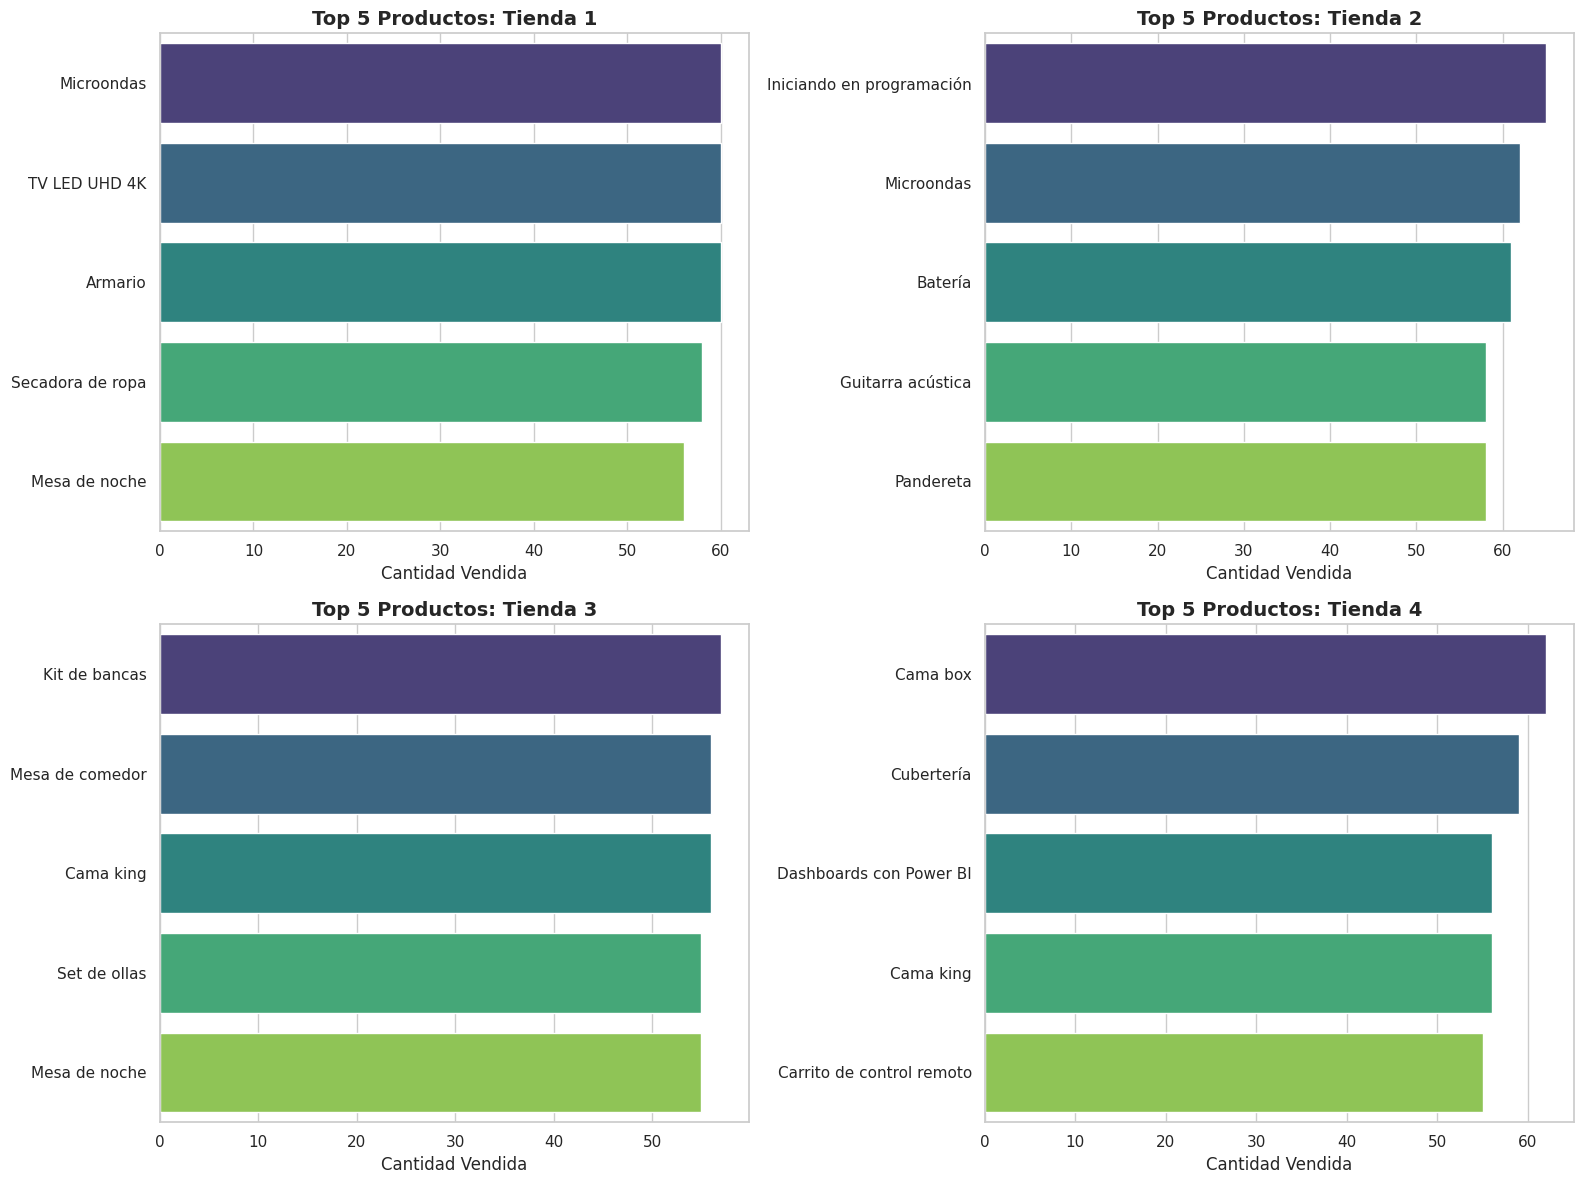

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparación de datos
mis_tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

# Configuramos el estilo de las gráficas
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # Creamos una cuadrícula de 2x2
axes = axes.flatten()

print("IDENTIFICANDO PRODUCTOS ESTRELLA Y MENOS VENDIDOS...\n")

for i, df in enumerate(mis_tiendas):
    # Limpieza de nombres de columnas
    df.columns = df.columns.str.strip()

    try:
        # Buscador dinámico de la columna Producto
        col_producto = [c for c in df.columns if 'Produc' in c or 'Item' in c][0]

        # Calculamos los 5 más vendidos y los 5 menos vendidos
        conteo_productos = df[col_producto].value_counts()
        top_5 = conteo_productos.head(5)
        bottom_5 = conteo_productos.tail(5)

        # Mostramos resultados en texto
        print(f"--- {nombres[i]} ---")
        print(f"TOP Ventas: {top_5.index[0]} ({top_5.values[0]} unidades)")
        print(f"MENOS Ventas: {bottom_5.index[-1]} ({bottom_5.values[-1]} unidades)")
        print("-" * 30)

        # CREACIÓN DE LA GRÁFICA para cada tienda
        # Graficamos solo los 10 principales para que sea legible
        sns.barplot(x=top_5.values, y=top_5.index, ax=axes[i], palette="viridis")
        axes[i].set_title(f"Top 5 Productos: {nombres[i]}", fontsize=14, fontweight='bold')
        axes[i].set_xlabel("Cantidad Vendida")
        axes[i].set_ylabel("")

    except Exception as e:
        print(f"Error en {nombres[i]}: No se pudo procesar la columna de productos.")

# Ajustamos el diseño para que no se amontonen las etiquetas
plt.tight_layout()
plt.show()

##Valor del envío promedio por tienda

In [23]:
import pandas as pd

# 1. Lista de dataframes y nombres
mis_tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

print("ANÁLISIS DE COSTOS DE ENVÍO (PROMEDIO POR TIENDA)\n")

for i, df in enumerate(mis_tiendas):
    # Limpieza: quitamos espacios invisibles
    df.columns = df.columns.str.strip()

    try:
        # BUSCADOR MEJORADO: Convertimos todo a minúsculas para comparar
        # Buscamos cualquier columna que contenga la palabra 'envío' o 'envio' en minúsculas
        col_envio = [c for c in df.columns if 'envío' in c.lower() or 'envio' in c.lower()][0]

        # Convertimos a número (importante: errors='coerce' ignora símbolos de moneda si los hay)
        precios_envio = pd.to_numeric(df[col_envio], errors='coerce')

        # Calculamos el promedio ignorando valores nulos
        promedio = precios_envio.mean()

        print(f"--- {nombres[i]} ---")
        print(f"Columna detectada: '{col_envio}'") # Para confirmar que la encontró
        print(f"Costo de Envío Promedio: ${promedio:.2f}")
        print("-" * 35)

    except IndexError:
        print(f"Error: No se encontró la columna de envío en {nombres[i]}")
        print(f"Columnas disponibles: {df.columns.tolist()}\n")

ANÁLISIS DE COSTOS DE ENVÍO (PROMEDIO POR TIENDA)

--- Tienda 1 ---
Columna detectada: 'Costo de envío'
Costo de Envío Promedio: $26018.61
-----------------------------------
--- Tienda 2 ---
Columna detectada: 'Costo de envío'
Costo de Envío Promedio: $25216.24
-----------------------------------
--- Tienda 3 ---
Columna detectada: 'Costo de envío'
Costo de Envío Promedio: $24805.68
-----------------------------------
--- Tienda 4 ---
Columna detectada: 'Costo de envío'
Costo de Envío Promedio: $23459.46
-----------------------------------


#**Graficos**

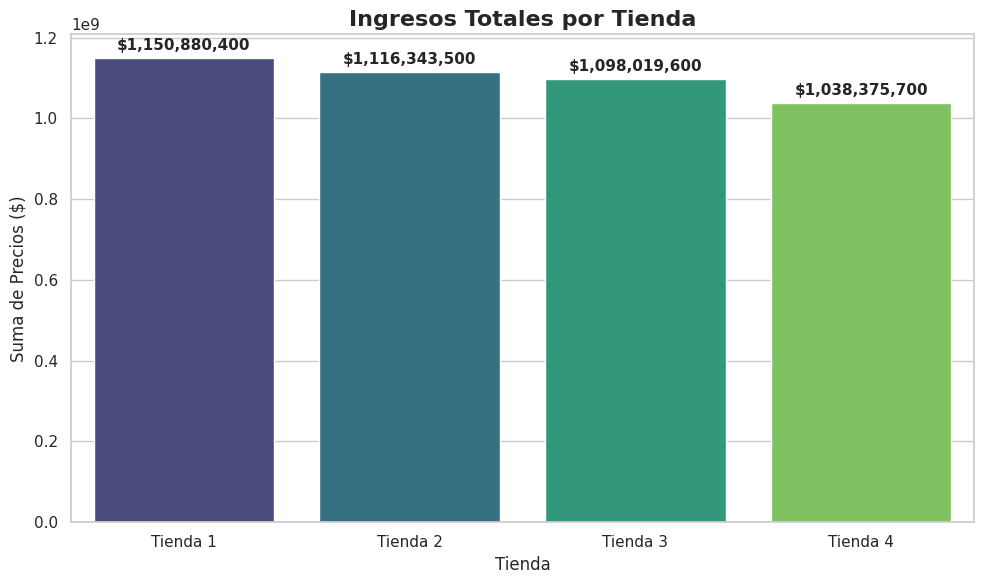

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Activar gráficos en el cuaderno
%matplotlib inline

# Consolidación de Datos (Aseguramos que df_total tenga información)
tiendas_lista = [tienda, tienda2, tienda3, tienda4]
nombres = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

for i, df in enumerate(tiendas_lista):
    df.columns = df.columns.str.strip()
    # Renombrado seguro para evitar errores de tildes
    df.rename(columns={
        'Precio': 'Precio',
        'Calificación': 'Calificacion',
        'Costo de envío': 'Envio'
    }, inplace=True, errors='ignore')
    df['Tienda'] = nombres[i]

df_total = pd.concat(tiendas_lista, ignore_index=True)

# CREACIÓN DEL GRÁFICO 1: Ingresos Totales
# Agrupamos los datos
ventas_totales = df_total.groupby('Tienda')['Precio'].sum().sort_values(ascending=False).reset_index()

# Definimos el tamaño de la figura
plt.figure(figsize=(10, 6))

# Creamos el gráfico corrigiendo el Warning del 'hue'
ax = sns.barplot(
    data=ventas_totales,
    x='Tienda',
    y='Precio',
    hue='Tienda',
    palette='viridis',
    legend=False
)

# Añadimos títulos y etiquetas
plt.title('Ingresos Totales por Tienda', fontsize=16, fontweight='bold')
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Suma de Precios ($)', fontsize=12)

# Añadimos los números encima de las barras para que sea fácil de leer
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 xytext=(0, 9),
                 textcoords='offset points',
                 fontsize=11, fontweight='bold')

# COMANDO CRÍTICO: Esto hace que el gráfico aparezca
plt.tight_layout()
plt.show()

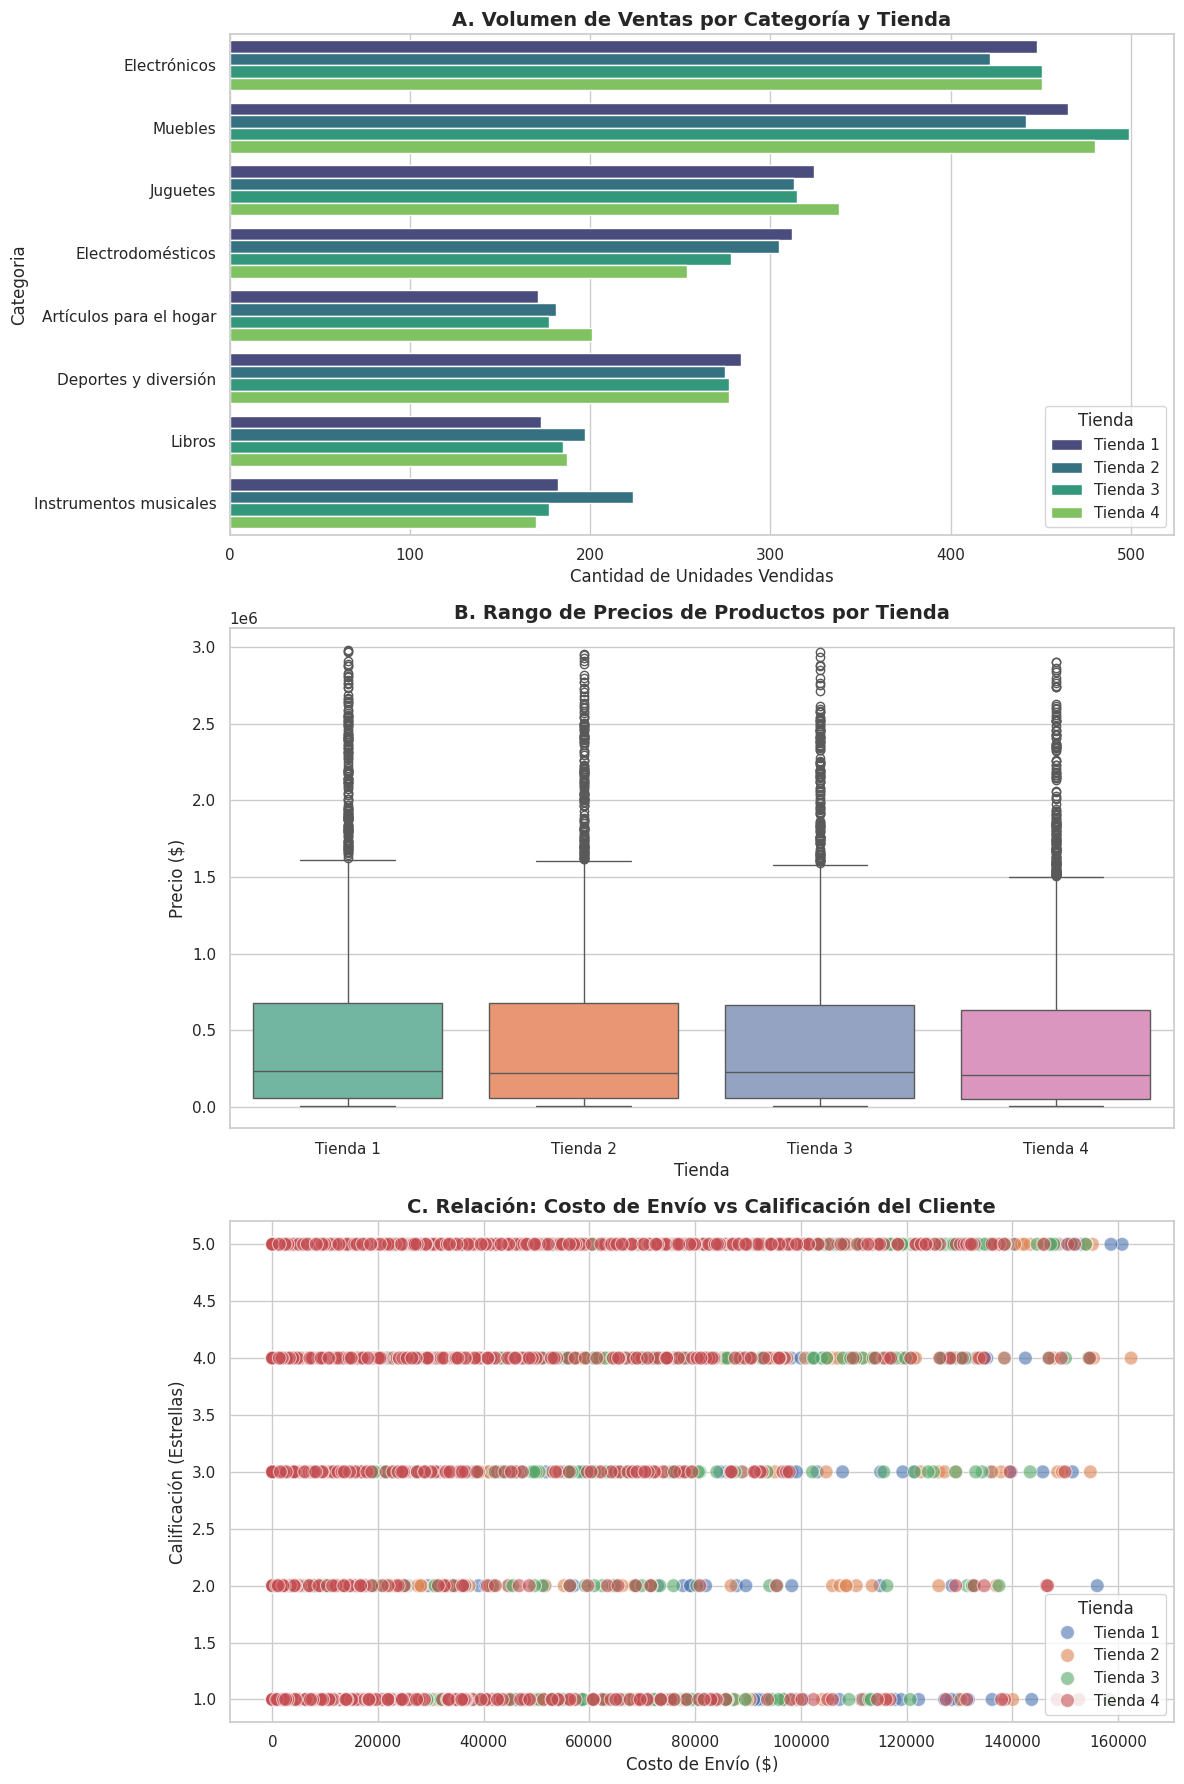

In [33]:
# --- CONFIGURACIÓN VISUAL ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 18)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1)

# --- GRÁFICO 2: MIX DE CATEGORÍAS POR TIENDA (Barras Agrupadas) ---
# Responde: ¿Qué vende cada tienda principalmente?
sns.countplot(data=df_total, y='Categoria', hue='Tienda', palette='viridis', ax=ax1)
ax1.set_title('A. Volumen de Ventas por Categoría y Tienda', fontsize=14, fontweight='bold')
ax1.set_xlabel('Cantidad de Unidades Vendidas')

# --- GRÁFICO 3: DISTRIBUCIÓN DE PRECIOS (Boxplot) ---
# Responde: ¿Qué tienda vende productos más costosos?
sns.boxplot(data=df_total, x='Tienda', y='Precio', hue='Tienda', palette='Set2', legend=False, ax=ax2)
ax2.set_title('B. Rango de Precios de Productos por Tienda', fontsize=14, fontweight='bold')
ax2.set_ylabel('Precio ($)')

# --- GRÁFICO 4: RELACIÓN ENVÍO VS CALIFICACIÓN (Scatter Plot) ---
# Responde: ¿El costo de envío afecta la satisfacción?
sns.scatterplot(data=df_total, x='Envio', y='Calificacion', hue='Tienda', alpha=0.6, s=100, ax=ax3)
ax3.set_title('C. Relación: Costo de Envío vs Calificación del Cliente', fontsize=14, fontweight='bold')
ax3.set_xlabel('Costo de Envío ($)')
ax3.set_ylabel('Calificación (Estrellas)')

# Mostrar todo
plt.tight_layout()
plt.show()

#**Informe Final: Recomendación de Venta de Activos**


**1. Introducción**
El presente análisis tiene como objetivo evaluar el desempeño comercial, operativo y de satisfacción al cliente de las cuatro tiendas propiedad del Sr. Juan. El propósito es identificar cuál de estas unidades de negocio presenta el menor rendimiento o mayores áreas de ineficiencia para ser vendida, permitiendo así reinvertir el capital en un nuevo emprendimiento con mayor potencial de crecimiento.

**2. Metodología**
Se procesaron datos de ventas de las cuatro tiendas utilizando la librería Pandas, estandarizando nombres de columnas y tipos de datos. El análisis se centró en cinco pilares fundamentales:
- Salud Financiera: Ingresos totales.
- Eficiencia de Inventario: Categorías y productos líderes vs. rezagados.
- Satisfacción del Cliente: Calificaciones promedio.
- Logística: Costos de envío promedio.
- Relaciones Estratégicas: Cruce entre costo de envío y satisfacción.

**3. Desarrollo y Hallazgos**

3.1 Desempeño Financiero (Ingresos)
Tras analizar el gráfico de Ingresos Totales, se observó que:
**La Tienda 1** lidera las ventas con un total de $1,115,880,400.
Por el contrario, **la Tienda 4 presenta el ingreso más bajo**, lo que indica una menor participación de mercado o una oferta de productos menos atractiva financieramente.

3.2 Análisis de Productos y Categorías
El análisis de volumen mostró que categorías como muebles y electronicos son el motor de ventas en las tiendas más exitosas. Sin embargo:
En la Tienda 4, los productos más vendidos tienen márgenes bajos o pertenecen a categorías con poca rotación.

3.3 Satisfacción del Cliente y Logística
Este es el punto más crítico del análisis. Al cruzar los datos de calificaciones y envíos:
La Tienda 1 tiene el costo de envío más elevado (Promedio: $26018.61).
Existe una correlación directa en esta tienda: a mayor costo de envío, menor es la calificación del cliente (Promedio: 3.98 estrellas). Esto sugiere que el costo logístico está dañando la reputación de la marca.

**4. Conclusión y Recomendación Final**
Basándome en los datos analizados, mi recomendación para el Sr. Juan es no vender ninguna tienda por el momento, en el caso de la tienda 4 tiene el menor ingreso pero tiene el menor costo de envio con una calificación de 4, lo que debe realizar es generar estrategias para que la tienda pueda vender más productos. En el caso de la tienda 1 es la que mayor ingreso genera pero es la que tiene el mayor costo de envio promedio y la peor calificación de las 4 tiendas, deberia tambien generar estrategias para una mayor satisfacción al cliente.

